# Ecommerce Customer Churn Analysis and Prediction

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              roc_curve, precision_recall_curve, average_precision_score)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings('ignore')  # Suppresses warnings to keep the output clean.

## 2. Overview Dataset

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in df.columns if c not in numerical_cols]
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Categorical Columns: ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [6]:
# cek Missing values, duplicates, unique counts
missing = df.isnull().sum()
summary = pd.DataFrame({
    "dtypes": df.dtypes.astype(str),
    "missing_values": missing,
    "missing_pct": (missing / len(df) * 100).round(2),
    "unique_values": df.nunique()
})
print("Duplicate rows (all columns identical):", df.duplicated().sum())
print("Duplicate customerID values:", df['customerID'].duplicated().sum())
summary

Duplicate rows (all columns identical): 0
Duplicate customerID values: 0


,dtypes,missing_values,missing_pct,unique_values
customerID,object,0,0.0,7043
gender,object,0,0.0,2
SeniorCitizen,int64,0,0.0,2
Partner,object,0,0.0,2
Dependents,object,0,0.0,2
tenure,int64,0,0.0,73
PhoneService,object,0,0.0,2
MultipleLines,object,0,0.0,3
InternetService,object,0,0.0,3
OnlineSecurity,object,0,0.0,3


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


       Count  Percentage
Churn                   
No      5174       73.46
Yes     1869       26.54


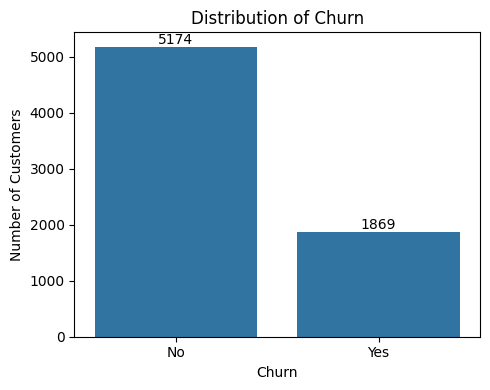

In [8]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': churn_counts, 'Percentage': churn_pct.round(2)}))

#visualisasi distribusi churn
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='Churn', order=['No', 'Yes'], ax=ax)
ax.set_title('Distribution of Churn')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
for  p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 3. Data Quality Audit

What are we doing? A serious audit: hidden missing values, whitespace, inconsistent categories, impossible values, and wrong data types.

Why? df.isnull().sum() reported zero missing values everywhere, but that only catches actual NaNs. TotalCharges is stored as text, which is suspicious for a currency amount - blank strings " " are not NaN, so isnull() misses them entirely.

What should we learn? Whether the data is genuinely clean, and - for anything that isn't - what caused the problem before deciding how to fix it.

In [9]:
# Attempt a safe numeric conversion and see what breaks
total_charges_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Row that fail numeric conversesion: {total_charges_numeric.isnull().sum()}")

problem_rows = df.loc[total_charges_numeric.isnull(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]
problem_rows

Row that fail numeric conversesion: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [10]:
# What do these problem rows have in common?
print("Unique tenure values among problem rows:", problem_rows['tenure'].unique())
print("Raw TotalCharges value(s):", repr(df.loc[total_charges_numeric.isnull(), 'TotalCharges'].unique()))
print("Churn outcomes among problem rows:", problem_rows['Churn'].value_counts().to_dict())

Unique tenure values among problem rows: [0]
Raw TotalCharges value(s): array([' '], dtype=object)
Churn outcomes among problem rows: {'No': 11}


Cleaning decision - TotalCharges:

- What problem was found? 11 rows (0.16% of the data) contain a whitespace string " " instead of a number, silently blocking any direct numeric conversion.
- Why does it matter? As text, the column can't be used in any model, correlation, or plot. But naively dropping the rows would discard 11 real customers for no good reason.
- What is the actual cause? Every one of these 11 rows has tenure == 0 - brand-new customers who have not completed a billing cycle, so they genuinely have not accumulated a cumulative charge yet. This is not random corruption; it is a logical consequence of TotalCharges being a running total.
- What solution was applied? Convert with pd.to_numeric(errors='coerce'), then fill these 11 NaNs with 0, since a customer with 0 months of tenure has by definition been billed $0 cumulatively. We do not drop them - they are valid, very new customers (and notably, none of them churned).

In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
print("missing values after conversion:", df['TotalCharges'].isnull().sum())
print("dtype:" , df['TotalCharges'].dtype)


missing values after conversion: 0
dtype: float64


In [12]:
# Further checks: whitespace, inconsistent labels, impossible values
obj_cols = [c for c in df.columns if df[c].dtype == object and c != 'customerID']

ws = {c: int((df[c].astype(str) != df[c].astype(str).str.strip()).sum()) for c in obj_cols}
print("Columns with leading/trailing whitespace:", {k: v for k, v in ws.items() if v > 0} or "None found")

print("\nCategory labels per column (checking for typos / inconsistent casing):")
for c in obj_cols:
    print(f"  {c}: {sorted(df[c].unique())}")

print("\nImpossible-value checks:")
print("  Negative tenure:", (df['tenure'] < 0).sum())
print("  Negative MonthlyCharges:", (df['MonthlyCharges'] < 0).sum())
print("  Negative TotalCharges:", (df['TotalCharges'] < 0).sum())
print("  Max tenure (months):", df['tenure'].max())
print("  TotalCharges < MonthlyCharges while tenure > 1:",
      int(((df['TotalCharges'] < df['MonthlyCharges']) & (df['tenure'] > 1)).sum()))

Columns with leading/trailing whitespace: None found

Category labels per column (checking for typos / inconsistent casing):
  gender: ['Female', 'Male']
  Partner: ['No', 'Yes']
  Dependents: ['No', 'Yes']
  PhoneService: ['No', 'Yes']
  MultipleLines: ['No', 'No phone service', 'Yes']
  InternetService: ['DSL', 'Fiber optic', 'No']
  OnlineSecurity: ['No', 'No internet service', 'Yes']
  OnlineBackup: ['No', 'No internet service', 'Yes']
  DeviceProtection: ['No', 'No internet service', 'Yes']
  TechSupport: ['No', 'No internet service', 'Yes']
  StreamingTV: ['No', 'No internet service', 'Yes']
  StreamingMovies: ['No', 'No internet service', 'Yes']
  Contract: ['Month-to-month', 'One year', 'Two year']
  PaperlessBilling: ['No', 'Yes']
  PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']
  Churn: ['No', 'Yes']

Impossible-value checks:
  Negative tenure: 0
  Negative MonthlyCharges: 0
  Negative TotalCharges: 0
  Max tenure (

Result of the audit: no whitespace issues, no inconsistent category spellings, no negative or impossible values, and tenure caps at a plausible 72 months. SeniorCitizen is stored as 0/1 rather than Yes/No like the other binary columns - not an error, just an inconsistent encoding convention worth remembering during EDA (it plots best as a category, not a continuous number). Aside from the TotalCharges fix, the dataset is clean.

## 4. Expaltory Data Analysis

### 4.1 Univariate Analysis

What are we doing? Examining the shape of the key numeric variables on their own, before looking at any relationship with churn.

Why? Distribution shape drives later choices: whether to scale features, whether "average" is even a meaningful summary, and whether sensible bins exist for grouping.

What should we learn? Whether these variables are well-behaved (roughly normal) or skewed/multi-modal in ways that hint at distinct customer sub-populations.

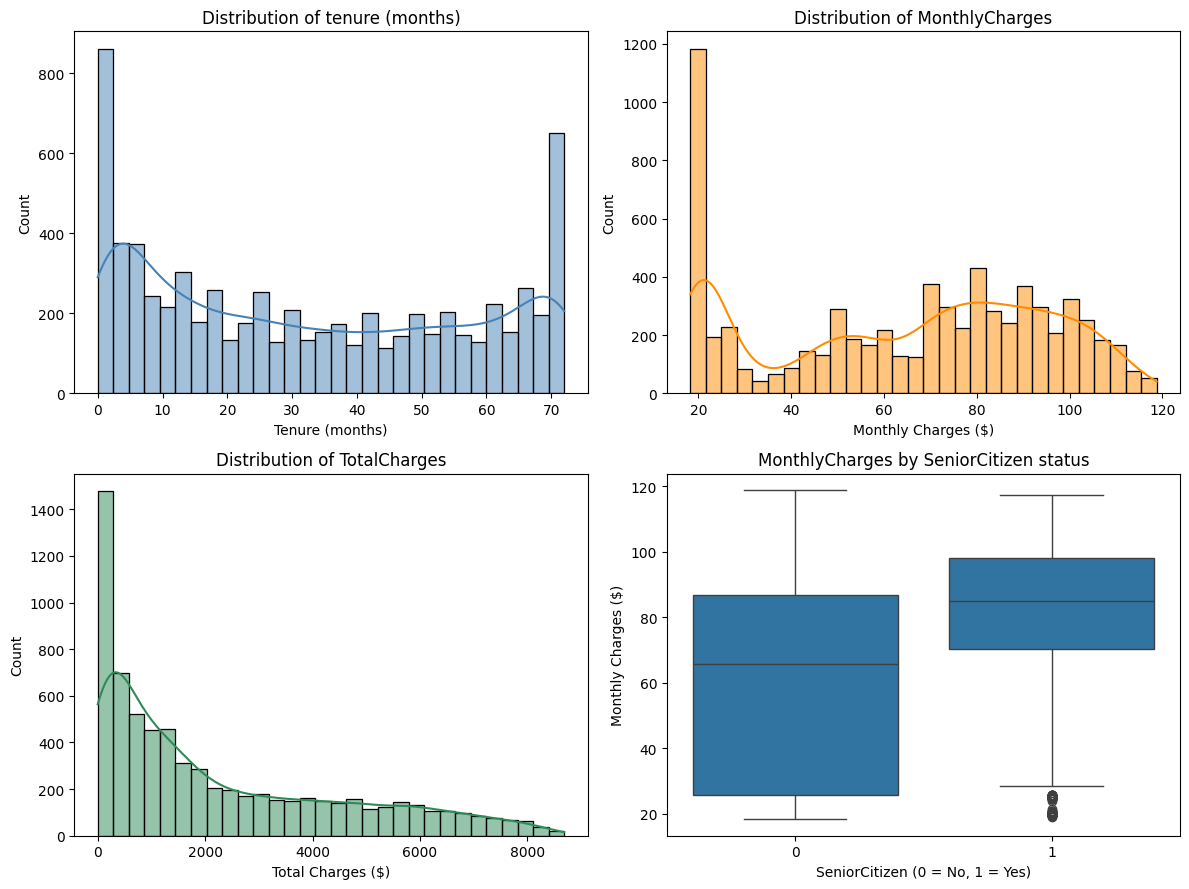

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


In [13]:
fig, axes =plt.subplots(2, 2, figsize=(12,9))

sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title("Distribution of tenure (months)")
axes[0, 0].set_xlabel("Tenure (months)")

sns.histplot(df['MonthlyCharges'], bins=30, kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title("Distribution of MonthlyCharges")
axes[0, 1].set_xlabel("Monthly Charges ($)")

sns.histplot(df['TotalCharges'], bins=30, kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title("Distribution of TotalCharges")
axes[1, 0].set_xlabel("Total Charges ($)")

sns.boxplot(data=df, y='MonthlyCharges', x='SeniorCitizen', ax=axes[1, 1])
axes[1, 1].set_title("MonthlyCharges by SeniorCitizen status")
axes[1, 1].set_xlabel("SeniorCitizen (0 = No, 1 = Yes)")
axes[1, 1].set_ylabel("Monthly Charges ($)")

plt.tight_layout()
plt.show()

print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2))

### 4.2 Categorical Variables vs. Churn

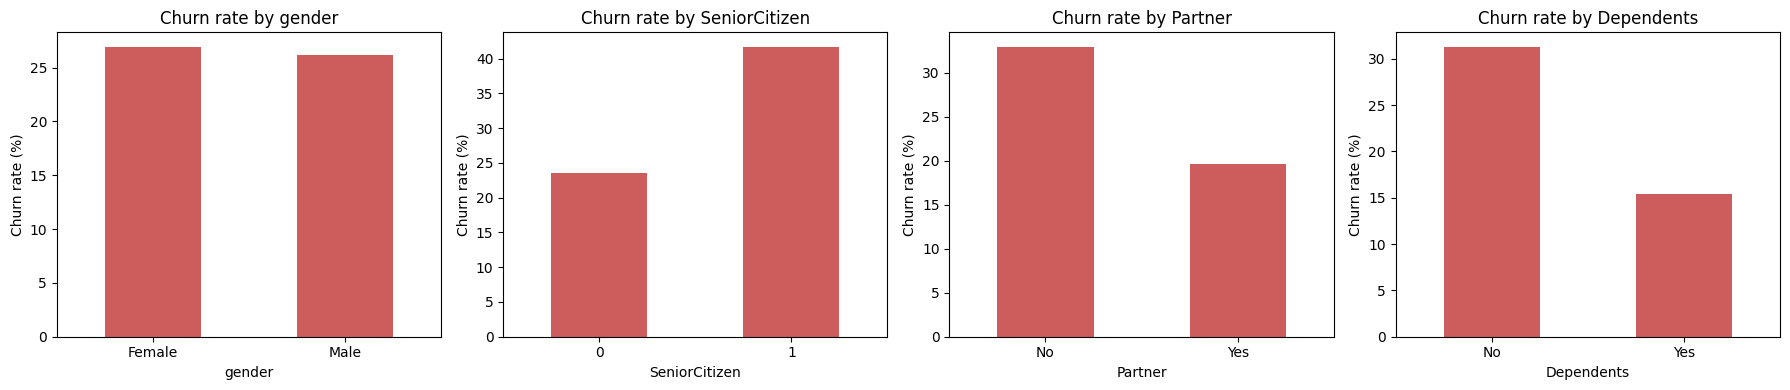

In [14]:
demo_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, demo_cols):
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    rate.plot(kind='bar', ax=ax, color='indianred')
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel(col)
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

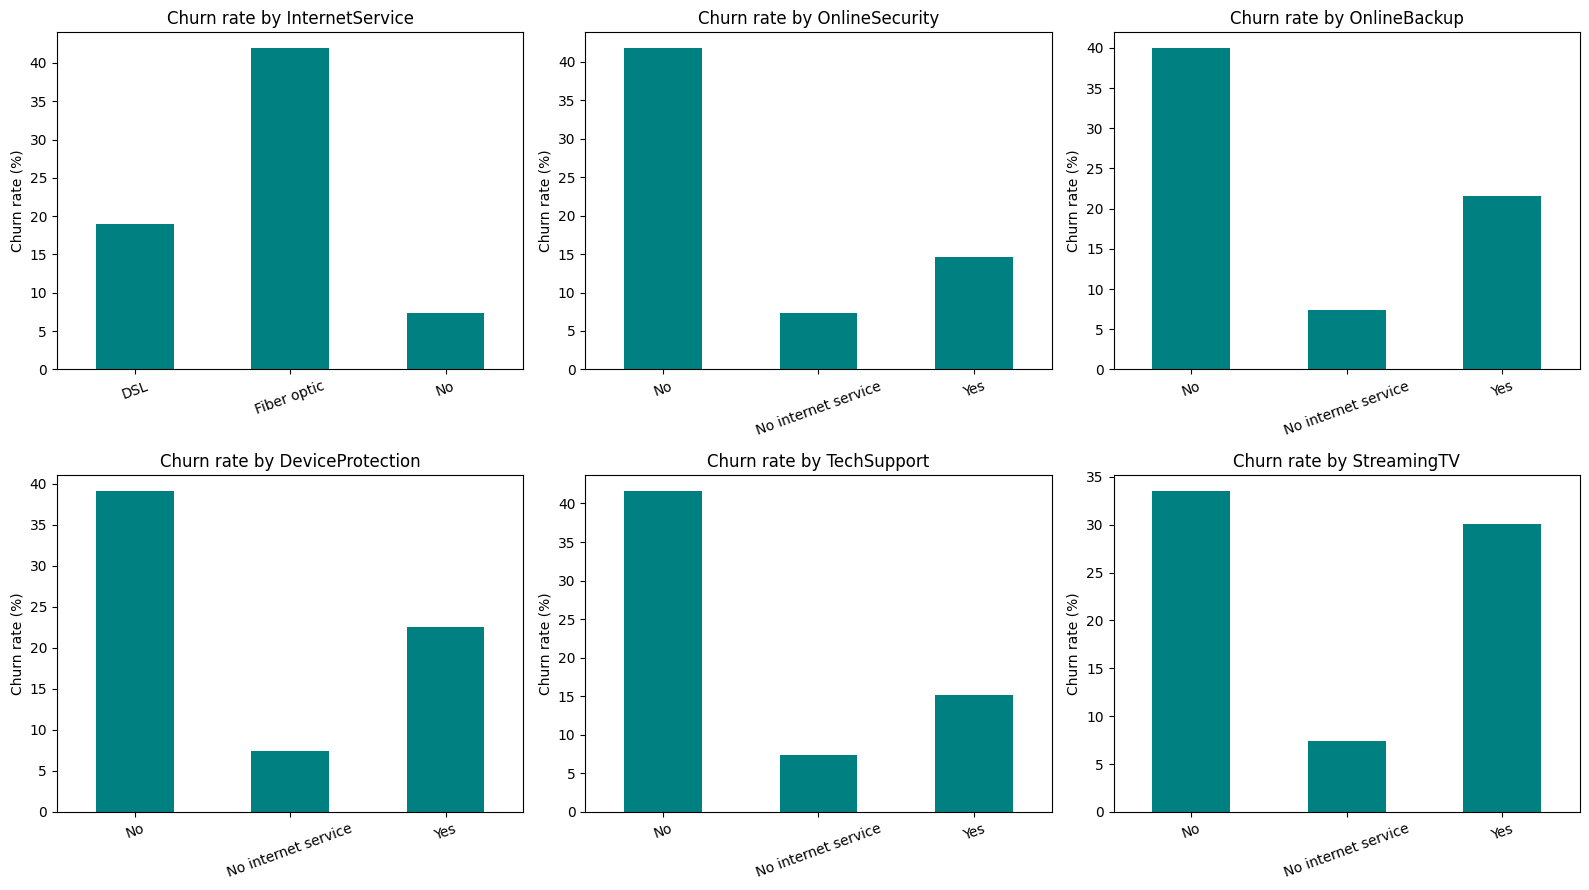

In [15]:
service_cols_plot = ['InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), service_cols_plot):
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    rate.plot(kind='bar', ax=ax, color='teal')
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

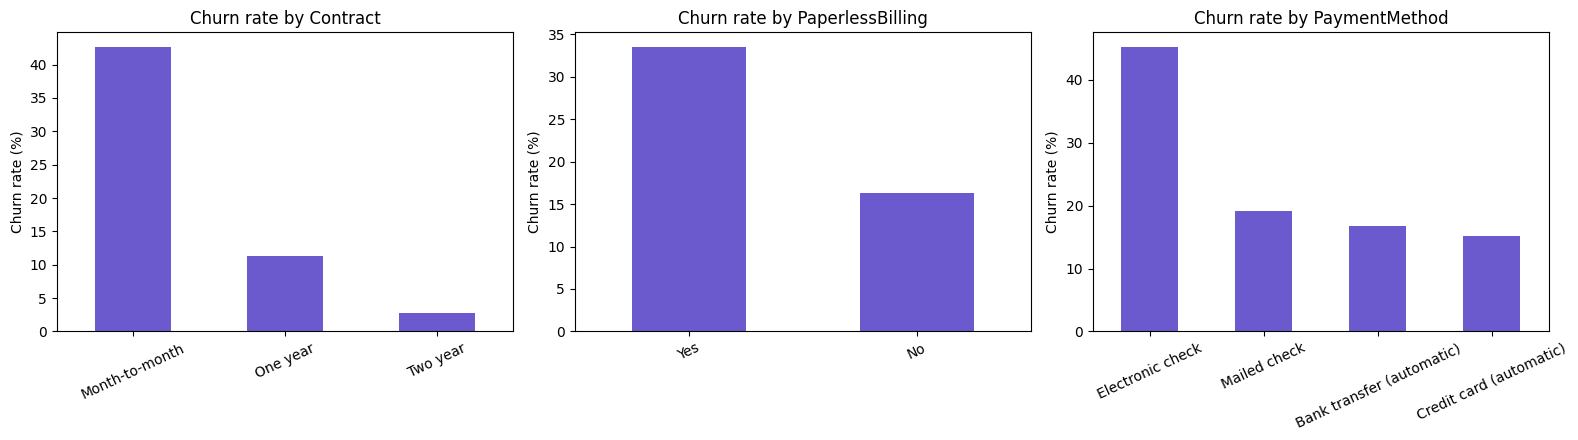

In [16]:
billing_cols_plot = ['Contract', 'PaperlessBilling', 'PaymentMethod']
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col in zip(axes, billing_cols_plot):
    rate = df.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean() * 100)
    rate.sort_values(ascending=False).plot(kind='bar', ax=ax, color='slateblue')
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

What stands out already:

- gender produces almost identical churn rates for Male vs. Female - visually flat, confirmed statistically in Section 6.
- SeniorCitizen, Partner, and Dependents all show a visible gap: seniors, customers without a partner, and customers without dependents churn more.
- Customers without OnlineSecurity or TechSupport churn substantially more than those with it, and Fiber optic customers churn far more than DSL or no-internet customers.
- Contract and PaymentMethod show the largest visual gaps so far - month-to-month contracts and electronic-check payments stand out sharply. We quantify these precisely next.

## 5. Customer Churn Patterns - Count vs. Rate

What are we doing? Reporting, for each segment, both the number of customers and the churn rate within it.

Why? A segment can look important simply because it is large. Raw counts answer "where are most of my churners?"; churn rate answers "where is churn most likely?" These are different questions with different answers, and conflating them is a classic analytical error.

$$
\text{Churn Rate} =
\frac{\text{Churned Customers in Segment}}
{\text{Total Customers in Segment}}
\times 100\%
$$
 
What should we learn? Which segments are genuinely high-risk, as distinct from merely large.

In [17]:
def churn_rate_table(data, col):
    t = data.groupby(col)['Churn'].agg(
        customer_count='size',
        churn_rate=lambda s: (s == 'Yes').mean() * 100
    )
    return t.sort_values('churn_rate', ascending=False)

for col in ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity', 'SeniorCitizen']:
    print(f"--- {col} ---")
    print(churn_rate_table(df, col).round(2))
    print()

--- Contract ---
                customer_count  churn_rate
Contract                                  
Month-to-month            3875       42.71
One year                  1473       11.27
Two year                  1695        2.83

--- InternetService ---
                 customer_count  churn_rate
InternetService                            
Fiber optic                3096       41.89
DSL                        2421       18.96
No                         1526        7.40

--- PaymentMethod ---
                           customer_count  churn_rate
PaymentMethod                                        
Electronic check                     2365       45.29
Mailed check                         1612       19.11
Bank transfer (automatic)            1544       16.71
Credit card (automatic)              1522       15.24

--- TechSupport ---
                     customer_count  churn_rate
TechSupport                                    
No                             3473       41.64
Yes        

### 5.1 Tenure Analysis
What are we doing? Grouping tenure into interpretable bands and measuring churn rate per band.

Why these bins? Rather than arbitrary or purely equal-width cuts, the bands are aligned to the contract lengths that actually exist in this dataset (1 and 2 years = 12 and 24 months), so each band maps to a real business milestone:

- 0-12 months: still inside a typical first-year window
- 13-24 months: through the one-year renewal point
- 25-48 months: established, multi-year customers
- 49+ months: the long-tenured, most loyal segment

These are a reasonable, explainable choice - not provably optimal. Section 8 tests how strongly the resulting grouping associates with churn, which is the check on whether the binning captured real signal.

              customer_count  churn_rate
tenure_group                            
0-12                    2186       47.44
13-24                   1024       28.71
25-48                   1594       20.39
49+                     2239        9.51


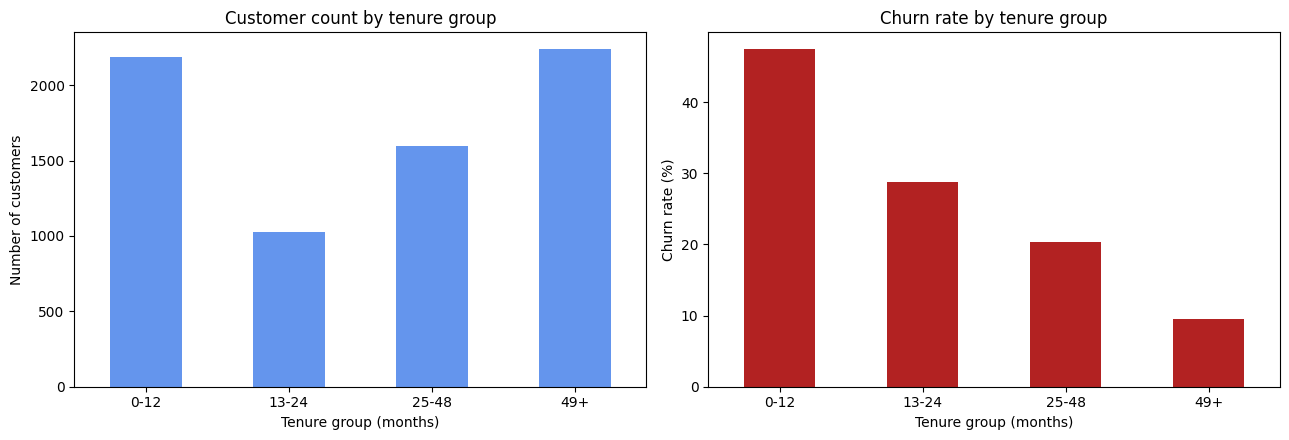

In [18]:
def tenure_group(t):
    if t <= 12:
        return '0-12'
    elif t <= 24:
        return '13-24'
    elif t <= 48:
        return '25-48'
    return '49+'

df['tenure_group'] = df['tenure'].apply(tenure_group)
order = ['0-12', '13-24', '25-48', '49+']

tenure_table = churn_rate_table(df, 'tenure_group').reindex(order)
print(tenure_table.round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
tenure_table['customer_count'].plot(kind='bar', ax=axes[0], color='cornflowerblue')
axes[0].set_title("Customer count by tenure group")
axes[0].set_ylabel("Number of customers")
axes[0].set_xlabel("Tenure group (months)")
axes[0].tick_params(axis='x', rotation=0)

tenure_table['churn_rate'].plot(kind='bar', ax=axes[1], color='firebrick')
axes[1].set_title("Churn rate by tenure group")
axes[1].set_ylabel("Churn rate (%)")
axes[1].set_xlabel("Tenure group (months)")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

## 6. Financial Analysis
- What are we doing? Examining MonthlyCharges, TotalCharges, and tenure in relation to churn.
- Why? Price is the variable business stakeholders reach for first, so it deserves careful treatment - including careful language.
- what should we learn? Whether spending is associated with churn, and why that association alone cannot support a pricing conclusion.

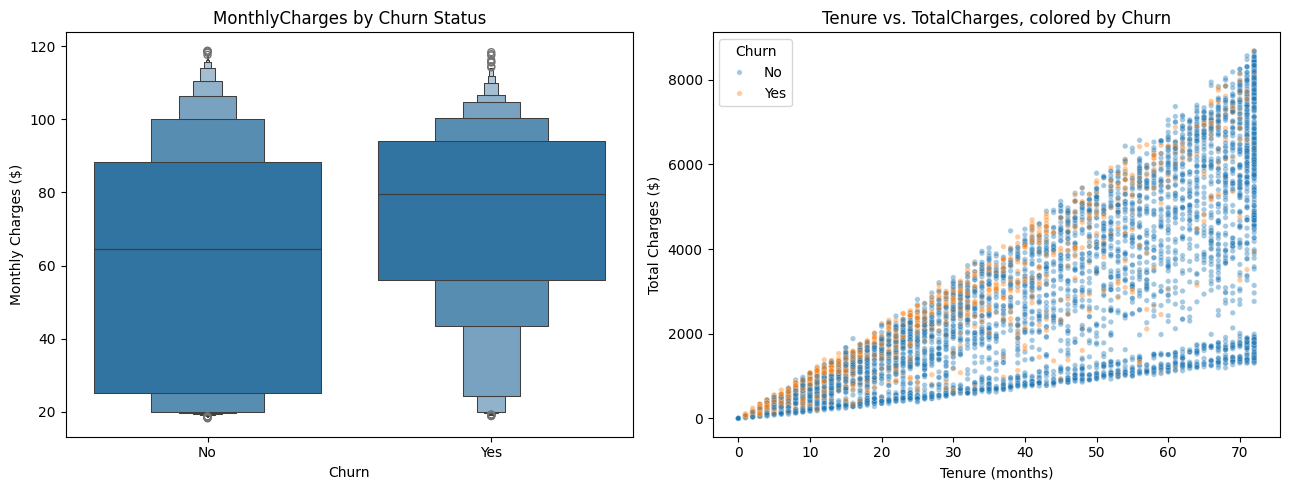

        mean    50%    std
Churn                     
No     61.27  64.43  31.09
Yes    74.44  79.65  24.67


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxenplot(data= df, x='Churn', y='MonthlyCharges', order= ['No', 'Yes'], ax=axes[0])
axes[0].set_title("MonthlyCharges by Churn Status")
axes[0].set_ylabel("Monthly Charges ($)")

sns.scatterplot(data=df, x='tenure', y='TotalCharges', hue='Churn', alpha=0.4, s = 15, ax=axes[1])
axes[1].set_title("Tenure vs. TotalCharges, colored by Churn")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Total Charges ($)")

plt.tight_layout()
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].describe()[['mean', '50%', 'std']].round(2))

Observations (association, not causation):

- Customers who churned have a higher median MonthlyCharges than customers who stayed. This aligns with the fiber-optic finding - fiber is the pricier internet tier and also the highest-churn one.
- The tenure-vs-TotalCharges scatter shows the two are naturally correlated (more months means more cumulative billing), and churned customers are visibly concentrated in the low-tenure, low-TotalCharges region.
- We deliberately avoid saying "higher prices cause churn." A defensible statement is: higher MonthlyCharges is associated with churn, largely because it correlates with fiber-optic internet and short tenure - both stronger, more specific signals. Testing a pricing hypothesis would require an experiment, not this dataset.

## 7. Multivariate Analysis
- What are we doing? Examining churn rate across combinations of variables.
- Why? Single-variable rates can mislead when the variables are themselves correlated. If fiber-optic customers are also disproportionately month-to-month, then attributing their churn to fiber alone double-counts the contract effect.
- What should we learn? Whether these effects are independent, compounding, or one merely standing in for another.

churn rate (%) by Contract and InternetService:
InternetService   DSL  Fiber optic    No
Contract                                
Month-to-month   32.2         54.6  18.9
One year          9.3         19.3   2.5
Two year          1.9          7.2   0.8


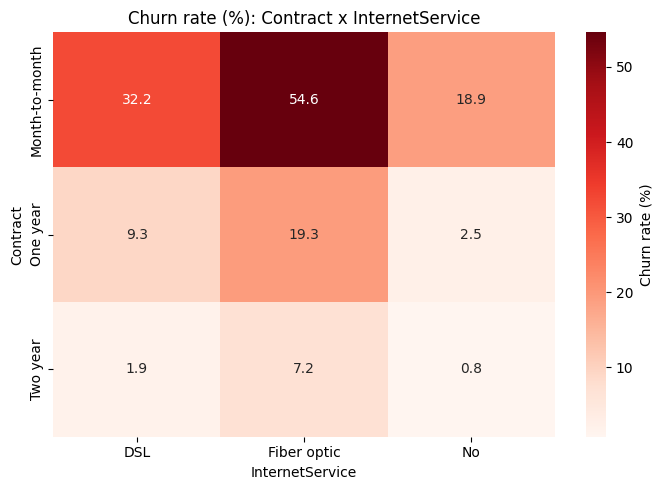

In [20]:
pivot1 = df.pivot_table(index='Contract', columns='InternetService', values='Churn', aggfunc=lambda s: (s == 'Yes').mean() * 100)
print("churn rate (%) by Contract and InternetService:")
print(pivot1.round(1))

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(pivot1, annot=True, fmt=".1f", cmap="Reds", ax=ax, cbar_kws={'label': 'Churn rate (%)'})
ax.set_title("Churn rate (%): Contract x InternetService")
plt.tight_layout()
plt.show()

churn rate (%) by Contract and PaymentMethod:
Contract                   Month-to-month  One year  Two year
PaymentMethod                                                
Bank transfer (automatic)            34.1       9.7       3.4
Credit card (automatic)              32.8      10.3       2.2
Electronic check                     53.7      18.4       7.7
Mailed check                         31.6       6.8       0.8


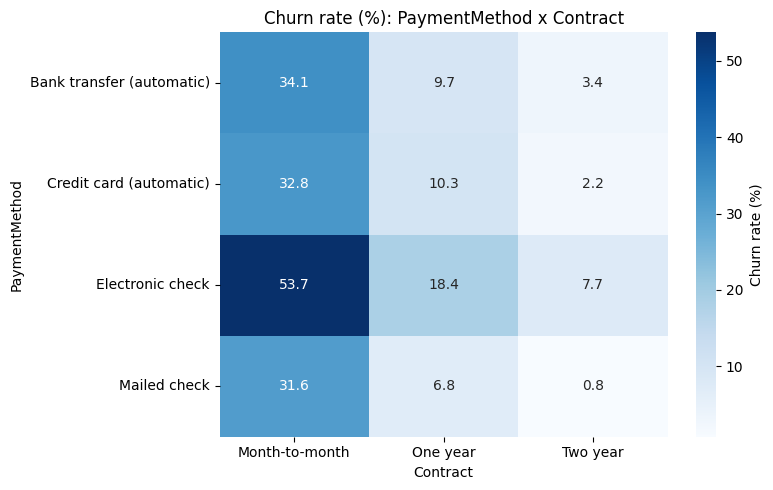

In [21]:
pivot2 = df.pivot_table(index='PaymentMethod', columns='Contract', values='Churn', aggfunc=lambda s: (s == 'Yes').mean() * 100)
print("churn rate (%) by Contract and PaymentMethod:")
print(pivot2.round(1))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot2, annot=True, fmt=".1f", cmap="Blues", ax=ax, cbar_kws={'label': 'Churn rate (%)'})
ax.set_title("Churn rate (%): PaymentMethod x Contract")
plt.tight_layout()
plt.show()

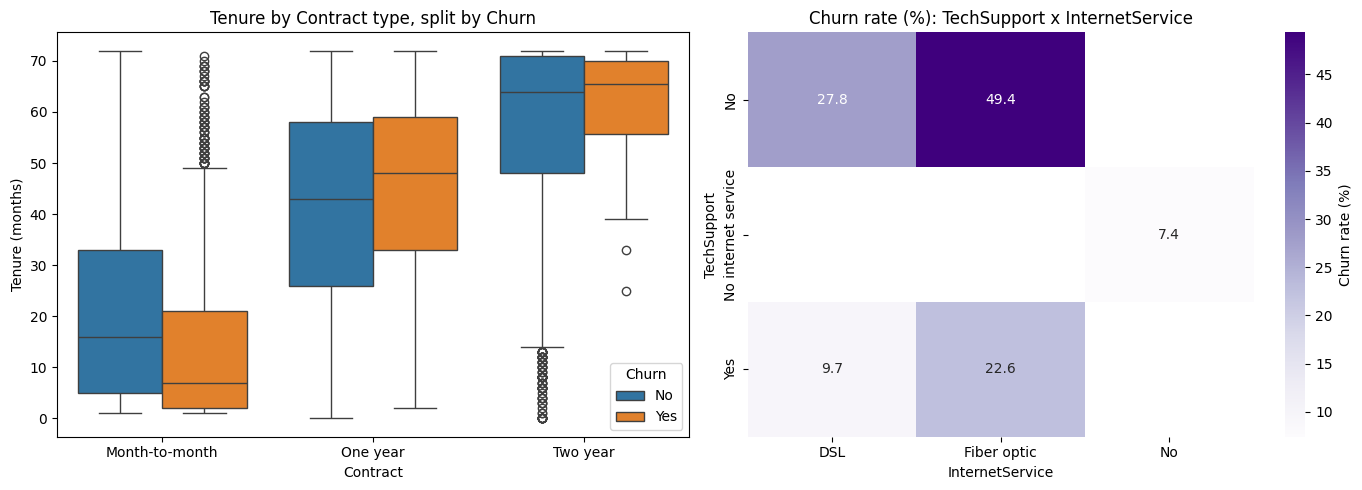

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Contract', y='tenure', hue='Churn', ax=axes[0])
axes[0].set_title("Tenure by Contract type, split by Churn")
axes[0].set_ylabel("Tenure (months)")

pivot3 = df.pivot_table(index='TechSupport', columns='InternetService', values='Churn',
                        aggfunc=lambda s: (s == 'Yes').mean() * 100)
sns.heatmap(pivot3, annot=True, fmt=".1f", cmap="Purples", ax=axes[1], cbar_kws={'label': 'Churn rate (%)'})
axes[1].set_title("Churn rate (%): TechSupport x InternetService")

plt.tight_layout()
plt.show()

Multivariate findings:

- The Contract x InternetService heatmap shows the two effects compound: month-to-month plus fiber-optic is the highest-churn combination in the grid, while two-year contracts with DSL or no internet are the safest. Neither variable alone tells the full story.
- PaymentMethod x Contract shows that within every contract type, electronic-check payers still churn more - so payment method carries some independent signal rather than acting purely as a proxy for contract type.
Within month-to-month contracts, churned customers skew toward much lower tenure than non-churned customers on the same contract - reinforcing that the danger zone is a new customer on a flexible contract.
- TechSupport x InternetService shows the support effect is concentrated among fiber-optic customers, where lacking tech support coincides with the highest churn rates of the grid.

## 8. Statistical Analysis: Correlation & Association
What are we doing? Measuring, with formal statistics, how strongly each variable relates to churn.

Why? Eyeballing bar charts is subjective. For numeric variables we use Pearson correlation. For categorical variables, treating them as numbers would be meaningless (Contract has no natural numeric order), so we instead use a chi-square test of independence (is there an association at all?) plus Cramer's V (how strong is it, on a 0-1 scale that corrects for sample size).

What should we learn? A defensible ranking of churn drivers, and which apparently-interesting variables are actually noise.

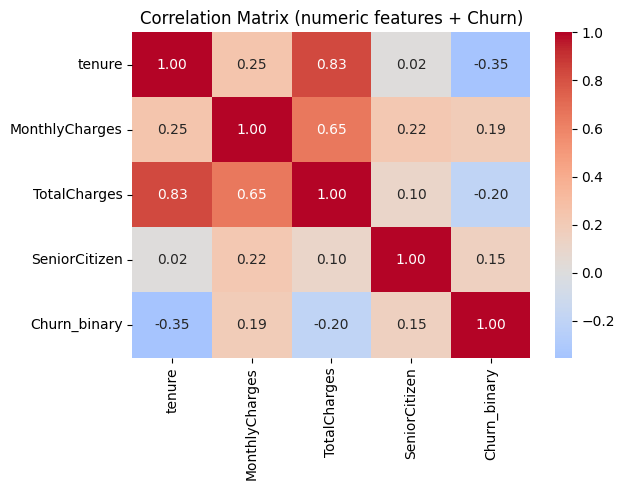

Correlation with Churn:
tenure           -0.352
MonthlyCharges    0.193
TotalCharges     -0.198
SeniorCitizen     0.151
Name: Churn_binary, dtype: float64


In [23]:
df['Churn_binary'] = (df["Churn"] == 'Yes').astype(int)
numeric_for_corr = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

corr = df[numeric_for_corr + ['Churn_binary']].corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,ax=ax)
ax.set_title("Correlation Matrix (numeric features + Churn)")
plt.tight_layout()
plt.show()

print("Correlation with Churn:")
print(corr['Churn_binary'].drop('Churn_binary').round(3))

In [24]:
from scipy import stats

def cramers_v(contingency_table):
    chi2 = stats.chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    phi2 = chi2 / n
    r, k = contingency_table.shape
    return np.sqrt(phi2 / min(k - 1, r - 1))

cat_cols_for_stats = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                      'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                      'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
                      'tenure_group']

rows = []
for col in cat_cols_for_stats:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, expected = stats.chi2_contingency(ct)
    rows.append({'feature': col, 'chi2_statistic': chi2, 'p_value': p,
                 'dof': dof, 'cramers_v': cramers_v(ct)})

assoc_df = pd.DataFrame(rows).sort_values('cramers_v', ascending=False).reset_index(drop=True)
assoc_df['significant_at_0.05'] = assoc_df['p_value'] < 0.05
assoc_df.round(4)

,feature,chi2_statistic,p_value,dof,cramers_v,significant_at_0.05
0,Contract,1184.5966,0.0000,2,0.4101,True
1,tenure_group,856.1002,0.0000,3,0.3486,True
2,OnlineSecurity,849.9990,0.0000,2,0.3474,True
3,TechSupport,828.1971,0.0000,2,0.3429,True
4,InternetService,732.3096,0.0000,2,0.3225,True
5,PaymentMethod,648.1423,0.0000,3,0.3034,True
6,OnlineBackup,601.8128,0.0000,2,0.2923,True
7,DeviceProtection,558.4194,0.0000,2,0.2816,True
8,StreamingMovies,375.6615,0.0000,2,0.2310,True
9,StreamingTV,374.2039,0.0000,2,0.2305,True


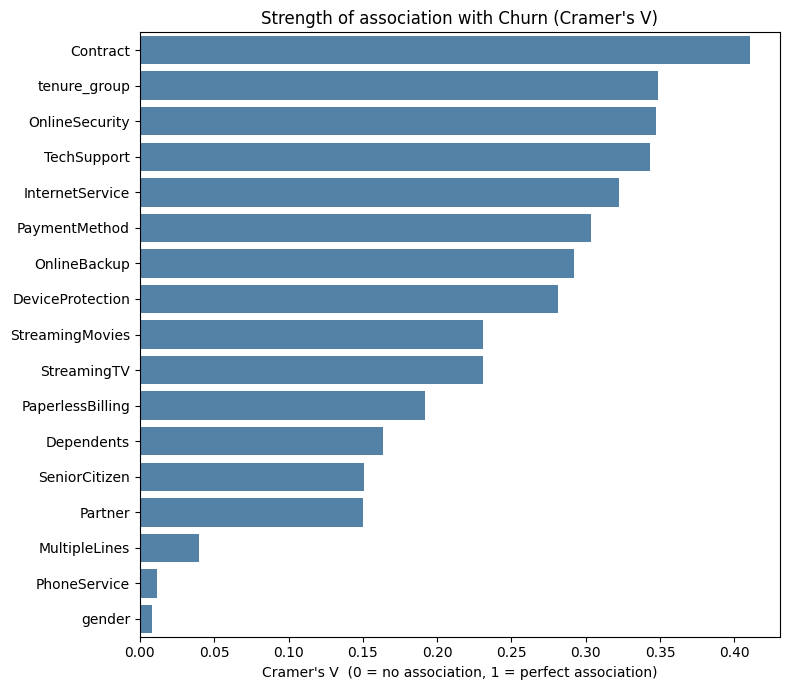

In [25]:
fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=assoc_df, y='feature', x='cramers_v', ax=ax, color='steelblue')
ax.set_title("Strength of association with Churn (Cramer's V)")
ax.set_xlabel("Cramer's V  (0 = no association, 1 = perfect association)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Interpretasi statistik:**

- **Korelasi numerik:** `tenure` (-0,35) adalah sinyal numerik terkuat - semakin lama masa berlangganan, semakin rendah churn. `TotalCharges` (-0,20) dan `MonthlyCharges` (+0,19) tergolong sedang; `SeniorCitizen` (+0,15) tergolong lemah hingga sedang.

- **Arti p-value di sini:** uji chi-square menanyakan, "jika `Contract` dan `Churn` sebenarnya tidak berhubungan dalam populasi, seberapa besar kemungkinan kita melihat pembagian yang sedemikian timpang hanya karena kebetulan?" P-value di bawah 0,05 berarti kebetulan saja bukan penjelasan yang memadai. Hampir semua variabel kategorikal menghasilkan p < 0,001 - **kecuali `gender` (p ≈ 0,49) dan `PhoneService` (p ≈ 0,34)**, yang tidak menunjukkan bukti asosiasi yang berarti dengan churn.

- **Cramer's V mengurutkan berdasarkan *besar* efek, bukan sekadar signifikansi.** Dengan 7.043 baris data, hubungan yang sangat kecil pun bisa menghasilkan p-value yang "signifikan" - Cramer's V mengoreksi hal ini. Berdasarkan ukuran ini, `Contract` (V ≈ 0,41), `tenure_group` (V ≈ 0,35), `OnlineSecurity` (V ≈ 0,35), dan `TechSupport` (V ≈ 0,34) adalah pendorong kategorikal terkuat, sedangkan `gender` (V ≈ 0,01) dan `PhoneService` (V ≈ 0,01) pada dasarnya tidak berhubungan. `MultipleLines` adalah kasus menengah yang instruktif: signifikan secara statistik (p ≈ 0,003) tetapi dengan V ≈ 0,04, artinya nyata namun secara praktis dapat diabaikan - persis perbedaan yang tidak akan terlihat jika hanya melihat p-value.

- **Keterbatasan:** chi-square hanya menguji asosiasi, bukan mekanisme atau arah hubungan. Kuatnya asosiasi antara `Contract` dan churn tidak menjelaskan *mengapa*: pelanggan bulanan (month-to-month) mungkin memang kurang berkomitmen, atau biaya berpindah yang rendah pada kontrak itu sendiri yang memudahkan mereka pergi, atau keduanya, atau ada faktor lain yang tidak terukur. Data cross-sectional tidak dapat membedakan kemungkinan-kemungkinan ini. Chi-square juga mengasumsikan jumlah sel harapan yang memadai (terpenuhi di sini mengingat ukuran sampel) dan memperlakukan setiap pelanggan sebagai independen.

## 9. Feature Engineering
**Apa yang kita lakukan?** Menambahkan sejumlah kecil fitur - dan, yang sama pentingnya, menjelaskan alasan untuk fitur yang tidak kita tambahkan.

**Mengapa?** Jumlah fitur bukanlah ukuran kualitas. Setiap fitur baru harus dapat diinterpretasikan, menambah informasi yang belum ada, dan dapat dihitung dari data yang tersedia sebelum hasil churn diketahui (tanpa kebocoran/*leakage*).

**Fitur yang dibuat:**

1. `tenure_group` - pengelompokan empat kelompok dari Bagian 5.1. Fitur ini berguna untuk pelaporan segmen yang mudah dibaca, tetapi karena merupakan diskretisasi murni dari `tenure` (yang sudah menjadi fitur model), fitur ini **dikecualikan dari input model**. Menyertakan keduanya akan menimbulkan redundansi antara dua penyandian dari informasi yang sama, sekaligus mengurangi resolusi, tanpa menambah sinyal baru.

2. `total_services` - jumlah (0-8) layanan yang benar-benar dilanggan pelanggan, dari `PhoneService`, `MultipleLines`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies` (hanya menghitung "Yes"). Fitur ini meringkas delapan kolom ya/tidak yang jarang terisi menjadi satu sinyal yang mudah diinterpretasikan tentang "seberapa terpaket pelanggan ini", yang terutama dapat langsung dimanfaatkan oleh model linear.

**Fitur yang sengaja TIDAK dibuat:**

- Fitur "rata-rata tagihan bulanan" (`TotalCharges / tenure`) - terjadi pembagian dengan nol untuk 11 pelanggan dengan tenure 0, dan untuk pelanggan lainnya fitur ini hanya merekonstruksi `MonthlyCharges` yang sudah tersedia secara kurang lebih, sehingga menambah *noise* alih-alih informasi.

**Pemeriksaan kebocoran (*leakage*):** kedua fitur berasal semata-mata dari atribut pelanggan yang ada pada saat observasi. Tidak ada yang menggunakan `Churn`, dan tidak ada yang menggunakan informasi setelah hasil terjadi.

count    7043.00
mean        3.36
std         2.06
min         0.00
25%         1.00
50%         3.00
75%         5.00
max         8.00
Name: total_services, dtype: float64

Mean Services by churn status:
Churn
No     3.45
Yes    3.13
Name: total_services, dtype: float64


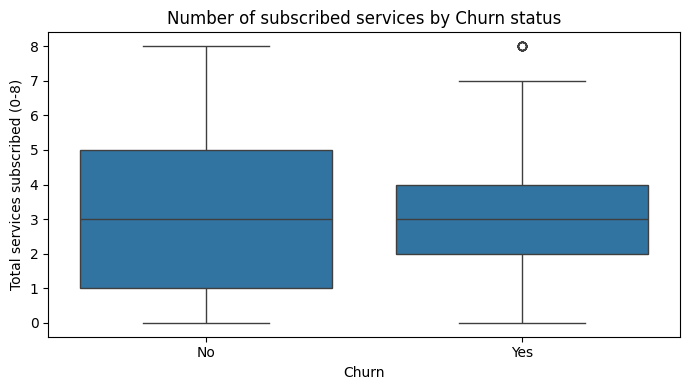

In [26]:
service_flag_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

df['total_services'] = (df[service_flag_cols] == 'Yes').sum(axis=1)

print(df['total_services'].describe().round(2))
print("\nMean Services by churn status:")
print(df.groupby('Churn')['total_services'].mean().round(2))

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='Churn', y='total_services', order=['No', 'Yes'], ax=ax)
ax.set_title("Number of subscribed services by Churn status")
ax.set_ylabel("Total services subscribed (0-8)")
plt.tight_layout()
plt.show()

Pelanggan yang churn rata-rata memiliki lebih sedikit layanan - konsisten dengan temuan sebelumnya bahwa pelanggan yang tidak memiliki layanan tambahan seperti `OnlineSecurity` atau `TechSupport` lebih sering churn, kini dinyatakan sebagai satu fitur gabungan.

## 10. Machine Learning Setup
**Apa yang kita lakukan?** Mendefinisikan masalah pemodelan dan membangun *pipeline* prapemrosesan yang aman dari kebocoran (*leakage*).

**Mengapa?** Di tahap inilah sebagian besar kesalahan halus muncul dalam sebuah proyek. Melakukan *fit* pada *scaler* atau *encoder* menggunakan seluruh dataset sebelum pemisahan data membuat informasi dari set uji memengaruhi pelatihan - sehingga skor menjadi terlalu tinggi dan tidak akan bertahan saat model dipakai di produksi.

**Keputusan desain:**

- **Target `y`:** `Churn` dalam bentuk biner (1 = Yes, 0 = No)
- **Fitur `X`:** semua kolom kecuali `customerID` (pengenal), `Churn`/`Churn_binary` (target), dan `tenure_group` (redundan dengan `tenure`, sesuai Bagian 9)
- **Pembagian data:** 80/20, terstratifikasi berdasarkan target sehingga kedua set mempertahankan tingkat churn sekitar 26,5%
- **Prapemrosesan:** fitur numerik distandardisasi, fitur kategorikal di-*one-hot encode*, keduanya di dalam satu `ColumnTransformer` yang dibungkus dalam `Pipeline`

**Jaminan tanpa kebocoran:** karena prapemrosesan berada di dalam `Pipeline`, `fit` hanya dipanggil pada data latih di setiap tahap - termasuk di dalam setiap *fold* validasi silang. *Scaler* tidak pernah melihat rata-rata dari set uji, dan *encoder* tidak pernah melihat kategori dari set uji (`handle_unknown='ignore'` menangani kategori baru yang muncul).

In [27]:
model_cols = [c for c in df.columns if c not in ['customerID', 'Churn', 'Churn_binary', 'tenure_group']]
X = df[model_cols]
y = df['Churn_binary']

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'total_services']
categorical_features = [c for c in model_cols if c not in numeric_features]

print(f"Total features: {len(model_cols)} ({len(numeric_features)} numeric, {len(categorical_features)} categorical)")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state= 42
)

print(f"\nTrain shape: {X_train.shape}   Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.4f}   Test churn rate: {y_test.mean():.4f}")

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features)
])

Total features: 20 (4 numeric, 16 categorical)

Train shape: (5634, 20)   Test shape: (1409, 20)
Train churn rate: 0.2654   Test churn rate: 0.2654


## 11. Baseline Model: Logistic Regresion
**Apa yang kita lakukan?** Melatih *Logistic Regression* yang sederhana dan mudah diinterpretasikan terlebih dahulu.

**Mengapa?** Tanpa titik acuan, tidak ada cara untuk mengetahui apakah model yang lebih kompleks benar-benar sepadan dengan kompleksitasnya. *Baseline* adalah tolok ukurnya.

**Mengapa akurasi saja tidak cukup untuk prediksi churn:** dengan pembagian kelas 73,5% / 26,5%, model sepele yang selalu memprediksi "tidak churn" akan mendapat akurasi ~73,5% padahal sama sekali tidak berguna - model itu tidak menemukan satu pun pelanggan yang churn, padahal itulah tujuan utama latihan ini. Akurasi menguntungkan kelas mayoritas. Oleh karena itu, selain akurasi kita juga melaporkan *precision* (dari yang ditandai, berapa yang benar-benar churn), *recall* (dari yang churn, berapa yang berhasil kita tangkap), F1 (rata-rata harmonik keduanya), dan ROC-AUC (kualitas peringkat yang tidak bergantung pada ambang batas).

Baseline Logistic Regression - Test set performance
  Accuracy : 0.8055
  Precision: 0.6562
  Recall   : 0.5615
  F1-score : 0.6052
  ROC-AUC  : 0.8421

  (Always-predict-'No-churn' accuracy would be: 0.7346)


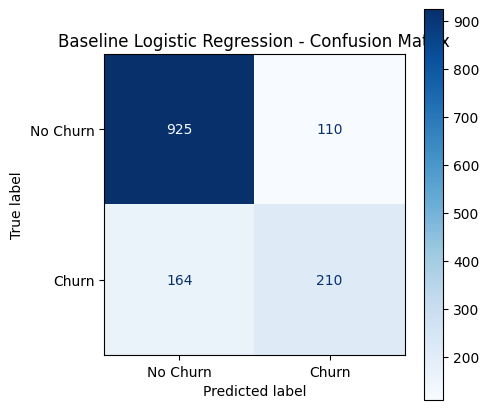

In [28]:
baseline_pipe = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_pipe.fit(X_train, y_train)

y_pred_base = baseline_pipe.predict(X_test)
y_proba_base = baseline_pipe.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression - Test set performance")
print(f"  Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred_base):.4f}")
print(f"  F1-score : {f1_score(y_test, y_pred_base):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, y_proba_base):.4f}")
print(f"\n  (Always-predict-'No-churn' accuracy would be: {1 - y_test.mean():.4f})")

fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_base,
                                        display_labels=['No Churn', 'Churn'], ax=ax, cmap='Blues')
ax.set_title("Baseline Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

Model dasar mencapai nilai ROC-AUC sekitar 0,84 — jauh di atas nilai 0,50 dari tebakan acak. Perhatikan perbandingan akurasi yang tercantum di atas: akurasi model ini hanya sedikit lebih baik daripada model dasar “do-nothing”, dan itulah tepatnya mengapa akurasi bukanlah metrik utama yang tepat dalam konteks ini. Recall juga terlihat jauh lebih rendah daripada precision pada ambang batas default 0,5, yang berarti model saat ini lebih konservatif dalam menandai churn daripada yang seharusnya. Bagian 16 membahas hal ini secara langsung.

## 12. Model Development & Comparison
**Apa yang kita lakukan?** Membandingkan lima *classifier* dengan prapemrosesan yang identik.

**Alasan setiap model disertakan** (bukan karena populer, melainkan karena tujuan tertentu):

| Model | Alasan disertakan |
|---|---|
| Logistic Regression | Linear, cepat, dan dapat langsung diinterpretasikan - *baseline* sekaligus andalan interpretabilitas kita |
| Decision Tree | Menangkap pemisahan non-linear dan interaksi yang tidak bisa ditangkap model linear; menguji apakah struktur seperti itu memang ada |
| Random Forest | *Ensemble* pohon; menguji apakah perataan (*averaging*) dapat mengatasi ketidakstabilan satu pohon |
| Gradient Boosting | Koreksi kesalahan secara berurutan; biasanya keluarga model terkuat pada data tabular berukuran menengah |
| HistGradientBoosting | Varian *boosting* berbasis histogram; menguji apakah *booster* yang lebih cepat dan diregularisasi secara berbeda memberi hasil lebih baik |

Setiap model dibungkus dalam `Pipeline` yang **sama**, sehingga perbandingan ini mengisolasi pengaruh algoritma, bukan prapemrosesan.

In [29]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42, max_depth=6),
    'Random Forest': RandomForestClassifier(random_state=42, max_depth=10, n_estimators=300),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['roc_auc', 'precision', 'recall', 'f1']

comparison_rows = []
for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    cv_res = cross_validate(pipe, X_train, y_train, cv=skf, scoring=scoring)
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    comparison_rows.append({
        'Model': name,
        'CV ROC-AUC Mean': cv_res['test_roc_auc'].mean(),
        'CV ROC-AUC Std': cv_res['test_roc_auc'].std(),
        'CV Precision': cv_res['test_precision'].mean(),
        'CV Recall': cv_res['test_recall'].mean(),
        'CV F1': cv_res['test_f1'].mean(),
        'Test ROC-AUC': roc_auc_score(y_test, y_proba),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Precision': precision_score(y_test, y_pred),
        'Test Recall': recall_score(y_test, y_pred),
        'Test F1': f1_score(y_test, y_pred),
    })

comparison_df = (pd.DataFrame(comparison_rows)
                 .sort_values('CV ROC-AUC Mean', ascending=False)
                 .reset_index(drop=True))
comparison_df.round(4)

,Model,CV ROC-AUC Mean,CV ROC-AUC Std,CV Precision,CV Recall,CV F1,Test ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1
0,LogisticRegression,0.8462,0.0127,0.6527,0.5438,0.5926,0.8421,0.8055,0.6562,0.5615,0.6052
1,Random Forest,0.8424,0.0098,0.6593,0.5137,0.5768,0.8388,0.8034,0.6644,0.5241,0.5859
2,HistGradientBoosting,0.8358,0.0065,0.6370,0.5184,0.5713,0.8324,0.7885,0.6210,0.5214,0.5669
3,DecisionTree,0.8239,0.0153,0.6293,0.5144,0.5634,0.8350,0.7921,0.6364,0.5053,0.5633


## 13. Cross-Validation
**Apa yang kita lakukan?** Tabel di atas sudah menggunakan validasi silang (*cross-validation*) terstratifikasi 5-*fold*; di sini kita memvisualisasikan sebarannya.

**Mengapa perlu validasi silang padahal kita sudah punya set uji terpisah (*held-out*)?** Satu kali pembagian data hanya menghasilkan satu estimasi, yang bisa terlalu optimistis atau terlalu pesimistis semata-mata karena keberuntungan dalam pembagiannya. Validasi silang terstratifikasi 5-*fold* melatih dan mengevaluasi model sebanyak lima kali pada potongan data latih yang berbeda, sehingga menghasilkan rata-rata sekaligus simpangan baku. Simpangan baku inilah bagian yang terpenting - ia menunjukkan seberapa besar skor akan berfluktuasi pada pembagian data yang berbeda, dan karena itu seberapa besar keyakinan yang layak diberikan pada selisih antara dua model. Stratifikasi menjaga tingkat churn tetap konstan di setiap *fold*, sehingga tidak ada *fold* yang dievaluasi pada sampel yang timpang.

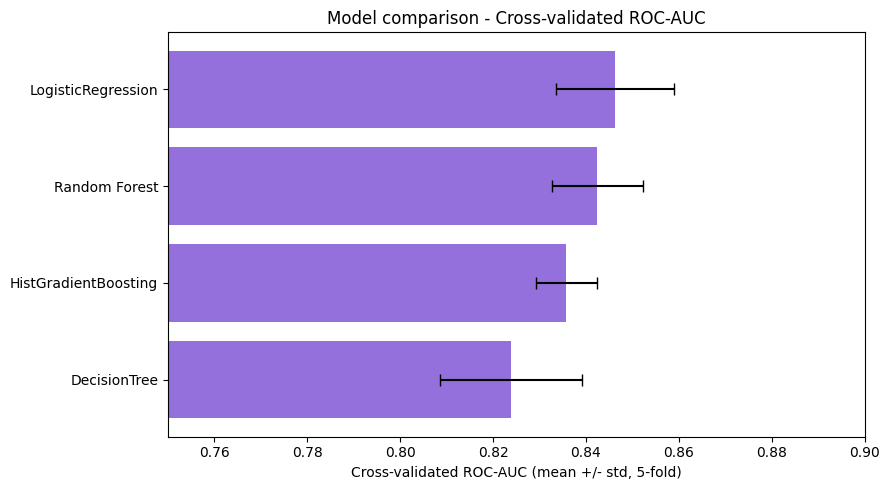

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = comparison_df.sort_values('CV ROC-AUC Mean')
ax.barh(plot_df['Model'], plot_df['CV ROC-AUC Mean'],
        xerr=plot_df['CV ROC-AUC Std'], color='mediumpurple', capsize=4)
ax.set_xlabel("Cross-validated ROC-AUC (mean +/- std, 5-fold)")
ax.set_title("Model comparison - Cross-validated ROC-AUC")
ax.set_xlim(0.75, 0.90)
plt.tight_layout()
plt.show()

## 14. MOdel Comparison & the Cost of Errors
**Membaca tabel:** kelima model berkumpul sangat rapat - ROC-AUC hasil validasi silang (CV) berkisar dari sekitar 0,824 (Decision Tree) hingga 0,848 (Gradient Boosting), dengan simpangan baku sekitar 0,01. Karena selisih antara model-model teratas sebanding dengan variasi antar-*fold*, Gradient Boosting dan Logistic Regression pada dasarnya setara, keduanya jelas lebih unggul daripada Decision Tree tunggal. Fakta bahwa model linear yang diregularisasi dengan baik mampu menyamai *ensemble* boosting menunjukkan bahwa sinyal churn pada data ini sebagian besar bersifat aditif, bukan didorong oleh interaksi yang kompleks.

**Pelajaran yang lebih luas:** pada dataset ini, pilihan algoritma jauh kurang berpengaruh dibandingkan sinyal mendasar yang sudah kita identifikasi di Bagian 5-8. Mengejar algoritma yang lebih baik akan memberi hasil lebih sedikit daripada memperoleh fitur yang lebih baik.

**Kita tidak memilih model berdasarkan akurasi.** Perhatikan pada tabel bahwa akurasi uji hanya sedikit berbeda antar model, sedangkan *recall* berbeda cukup besar - akurasi memang tidak sensitif terhadap hal yang paling kita pedulikan.

**False Positive vs. False Negative pada churn:**

- **False positive** menandai pelanggan sebagai berisiko padahal sebenarnya akan tetap bertahan. Biayanya: satu kontak retensi yang sia-sia, dan mungkin diskon yang diberikan tanpa perlu. Biasanya tergolong kecil, dan kadang bahkan positif (menumbuhkan niat baik pelanggan).
- **False negative** melewatkan pelanggan yang kemudian pergi. Biayanya: seluruh sisa nilai umur pelanggan (*lifetime value*) tersebut, tanpa kesempatan untuk melakukan intervensi. Biasanya jauh lebih besar.

Karena asimetri ini umumnya condong pada upaya menangkap lebih banyak pelanggan yang churn, program churn biasanya memilih *recall* yang lebih tinggi meskipun harus mengorbankan sebagian *precision* - hal ini merupakan keputusan ambang batas (*threshold*), bukan keputusan pemilihan model, dan akan dibahas di Bagian 16. Pengecualiannya adalah ketika penawaran retensi mahal atau kapasitas sangat terbatas, di mana *precision* menjadi lebih penting.

## 15. Hypeparameter Tuning
**Apa yang kita lakukan?** Melakukan *tuning* pada dua kandidat terkuat dari hasil validasi silang - Gradient Boosting dan Logistic Regression.

**Mengapa kedua model ini?** Keduanya dipilih berdasarkan hasil CV yang sebenarnya di atas, bukan berdasarkan reputasi.

**Mengapa `RandomizedSearchCV`?** *Grid* menyeluruh pada rentang parameter ini akan memerlukan ratusan kali pelatihan dengan manfaat yang kecil; pencarian acak menjelajahi ruang parameter secara efisien dengan anggaran tetap yang sederhana (masing-masing 15 dan 10 kandidat). *Tuning* berjalan di dalam validasi silang terstratifikasi yang sama, sehingga prapemrosesan tetap di-*fit* per *fold* dan tidak ada kebocoran (*leakage*) yang terjadi.

Kita sengaja hanya menyetel sedikit parameter: yaitu parameter yang benar-benar mengontrol kapasitas model (`learning_rate`, `max_depth`, `n_estimators` untuk *boosting*; kekuatan regularisasi `C` dan `class_weight` untuk *logistic regression*).

In [31]:
gb_pipe = Pipeline([('prep', preprocessor), ('clf', GradientBoostingClassifier(random_state=42))])
gb_param_dist = {
    'clf__n_estimators': [100, 150, 200, 300],
    'clf__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'clf__max_depth': [2, 3, 4, 5],
}
gb_search = RandomizedSearchCV(gb_pipe, gb_param_dist, n_iter=15, cv=skf,
                               scoring='roc_auc', random_state=42, n_jobs=-1)
gb_search.fit(X_train, y_train)

lr_pipe = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
lr_param_dist = {
    'clf__C': [0.01, 0.05, 0.1, 0.5, 1, 5, 10],
    'clf__class_weight': [None, 'balanced'],
}
lr_search = RandomizedSearchCV(lr_pipe, lr_param_dist, n_iter=10, cv=skf,
                               scoring='roc_auc', random_state=42, n_jobs=-1)
lr_search.fit(X_train, y_train)

print("Gradient Boosting   - best params:", gb_search.best_params_)
print(f"Gradient Boosting   - best CV ROC-AUC: {gb_search.best_score_:.4f}")
print("\nLogistic Regression - best params:", lr_search.best_params_)
print(f"Logistic Regression - best CV ROC-AUC: {lr_search.best_score_:.4f}")

best_gb = gb_search.best_estimator_
best_lr = lr_search.best_estimator_

gb_test_auc = roc_auc_score(y_test, best_gb.predict_proba(X_test)[:, 1])
lr_test_auc = roc_auc_score(y_test, best_lr.predict_proba(X_test)[:, 1])
print(f"\nTuned Gradient Boosting   - Test ROC-AUC: {gb_test_auc:.4f}")
print(f"Tuned Logistic Regression - Test ROC-AUC: {lr_test_auc:.4f}")

if gb_search.best_score_ >= lr_search.best_score_:
    final_model, final_name = best_gb, "Gradient Boosting (tuned)"
else:
    final_model, final_name = best_lr, "Logistic Regression (tuned)"

print(f"\nFinal model selected (on cross-validated ROC-AUC): {final_name}")

Gradient Boosting   - best params: {'clf__n_estimators': 100, 'clf__max_depth': 2, 'clf__learning_rate': 0.05}
Gradient Boosting   - best CV ROC-AUC: 0.8486

Logistic Regression - best params: {'clf__class_weight': None, 'clf__C': 10}
Logistic Regression - best CV ROC-AUC: 0.8464

Tuned Gradient Boosting   - Test ROC-AUC: 0.8428
Tuned Logistic Regression - Test ROC-AUC: 0.8412

Final model selected (on cross-validated ROC-AUC): Gradient Boosting (tuned)


*Tuning* hanya menghasilkan peningkatan kecil dibandingkan konfigurasi *default* tanpa *tuning* - hal ini memperkuat bahwa batas atas performa pada dataset ini ditentukan oleh kualitas fitur, bukan oleh upaya memeras algoritma lebih jauh. Konfigurasi Gradient Boosting yang terpilih cenderung menggunakan *learning rate* rendah dengan pohon yang dangkal (*shallow trees*), sebuah bentuk regularisasi bawaan yang masuk akal mengingat hanya ada sekitar 5.600 baris data latih dan risiko *overfitting* pada pohon yang lebih dalam.

Perlu dicatat, model dipilih berdasarkan skor hasil validasi silang, bukan skor set uji - memilih berdasarkan set uji akan menjadikannya seolah set latih kedua, sehingga evaluasi akhir menjadi bias secara optimistis.

## 16 Class Imbalance
**Apa yang kita lakukan?** Memutuskan bagaimana (dan apakah perlu) mengoreksi ketidakseimbangan target sekitar 73,5% / 26,5%.

**Pendekatan yang dibandingkan:**

- **`class_weight='balanced'`** - memberi penalti lebih besar pada kesalahan di kelas minoritas selama pelatihan. Pendekatan ini sudah dicoba dalam proses *tuning* Logistic Regression di atas, dan `class_weight=None` yang menang berdasarkan ROC-AUC hasil validasi silang, artinya pembobotan ulang tidak meningkatkan kualitas peringkat di sini.
- **Penyesuaian ambang batas (*threshold*)** - membiarkan probabilitas model apa adanya, dan menggeser titik potong yang mengubah probabilitas menjadi keputusan. Dibahas secara lengkap di bagian berikutnya.

**Mengapa kita TIDAK menerapkan SMOTE:** dengan rasio sekitar 3:1 dan kurang lebih 1.500 kasus churn dalam data latih, ketidakseimbangan ini tergolong ringan - ini bukan masalah kejadian langka (*rare-event*). SMOTE akan menambah kompleksitas yang nyata (pembuatan sampel sintetis yang harus dilakukan di dalam setiap *fold* CV agar tidak terjadi kebocoran, ditambah hyperparameter-nya sendiri) untuk mengatasi masalah yang sudah dapat ditangani secara lebih transparan oleh pembobotan kelas dan penyesuaian ambang batas. SMOTE juga menghasilkan titik-titik sintetis dengan cara interpolasi antar tetangga, yang secara konsep janggal untuk fitur kategorikal hasil *one-hot encoding* yang mendominasi dataset ini. Menerapkannya di sini hanya akan menjadi kompleksitas demi tampilan semata.

**Kesimpulan praktis:** penyesuaian ambang batas memberikan kendali yang lebih langsung dan mudah diinterpretasikan atas *trade-off* precision/recall dibandingkan pembobotan ulang maupun *oversampling*, sehingga itulah tuas (*lever*) yang kita gunakan.

## 17. Threshold Optimization
**Apa yang kita lakukan?** Menyapu (*sweeping*) ambang batas keputusan alih-alih menerima nilai *default*-nya begitu saja.

**Mengapa?** Sebuah *classifier* menghasilkan probabilitas; mengubahnya menjadi keputusan Ya/Tidak memerlukan titik potong (*cutoff*), dan 0,5 hanyalah nilai *default*, bukan nilai optimal. Nilai ini menyiratkan asumsi bahwa *false positive* dan *false negative* memiliki biaya yang sama - yang, seperti telah dibahas di Bagian 14, jarang benar untuk kasus churn.

- **Menurunkan ambang batas** menandai lebih banyak pelanggan sebagai berisiko: menangkap lebih banyak pelanggan yang benar-benar churn (*recall* lebih tinggi) dengan konsekuensi lebih banyak alarm palsu (*precision* lebih rendah).
- **Menaikkan ambang batas** lebih konservatif: alarm palsu lebih sedikit (*precision* lebih tinggi), tetapi lebih banyak pelanggan churn yang terlewat (*recall* lebih rendah).

**Apa yang perlu kita pelajari?** Bentuk dari *trade-off* ini - sehingga bisnis dapat memilih titik operasi dengan mengetahui apa yang didapat dan apa biayanya.

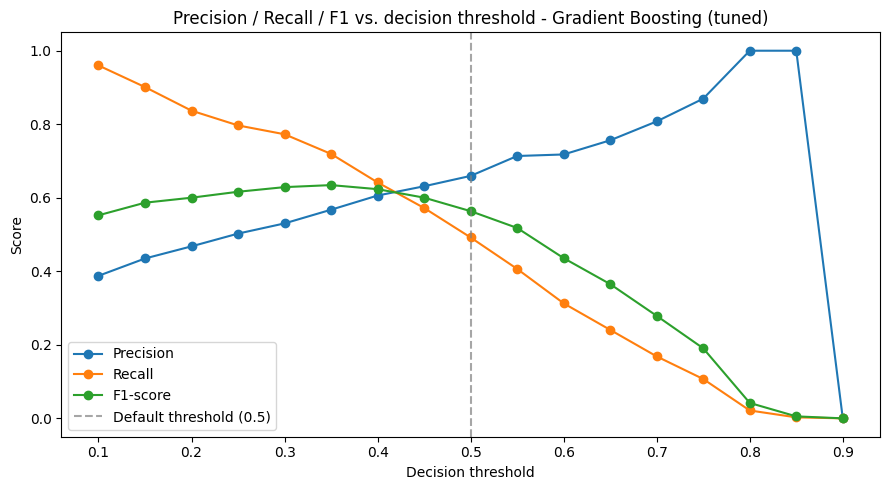

,threshold,precision,recall,f1,customers_flagged
0,0.10,0.388,0.960,0.552,926
1,0.15,0.435,0.901,0.587,775
2,0.20,0.468,0.837,0.600,669
3,0.25,0.503,0.797,0.616,593
4,0.30,0.530,0.773,0.629,545
5,0.35,0.568,0.719,0.634,474
6,0.40,0.606,0.642,0.623,396
7,0.45,0.631,0.572,0.600,339
8,0.50,0.659,0.492,0.564,279
9,0.55,0.714,0.406,0.518,213


In [33]:
y_proba_final = final_model.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.05)
threshold_rows = []
for t in thresholds:
    preds = (y_proba_final >= t).astype(int)
    threshold_rows.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, preds, zero_division=0),
        'recall': recall_score(y_test, preds, zero_division=0),
        'f1': f1_score(y_test, preds, zero_division=0),
        'customers_flagged': int(preds.sum()),
    })
threshold_df = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(threshold_df['threshold'], threshold_df['precision'], marker='o', label='Precision')
ax.plot(threshold_df['threshold'], threshold_df['recall'], marker='o', label='Recall')
ax.plot(threshold_df['threshold'], threshold_df['f1'], marker='o', label='F1-score')
ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='Default threshold (0.5)')
ax.set_xlabel("Decision threshold")
ax.set_ylabel("Score")
ax.set_title(f"Precision / Recall / F1 vs. decision threshold - {final_name}")
ax.legend()
plt.tight_layout()
plt.show()

threshold_df.round(3)


In [34]:
best_f1_row = threshold_df.loc[threshold_df['f1'].idxmax()]
print("Threshold that maximizes F1 on THIS test set:")
print(best_f1_row)

Threshold that maximizes F1 on THIS test set:
threshold              0.350000
precision              0.567511
recall                 0.719251
f1                     0.634434
customers_flagged    474.000000
Name: 5, dtype: float64


**Membaca kurva:** kedua garis saling berpotongan - *precision* naik secara stabil seiring bertambahnya ambang batas, sementara *recall* turun tajam, dan F1 mencapai puncaknya di titik tengah, yaitu sekitar 0,35 pada set uji ini. Pada titik tersebut, *recall* jauh lebih tinggi dibandingkan pada ambang batas 0,5, dengan konsekuensi nyata berupa penurunan *precision*.

Ini sama sekali **bukan berarti** "ambang batas terbaik". Ada tiga catatan penting:

1. Nilai ini optimal khusus untuk F1, dan F1 mengasumsikan bahwa *precision* dan *recall* sama pentingnya - ini adalah penilaian bisnis, bukan fakta statistik.
2. Nilai ini optimal untuk set uji tertentu ini; sampel yang berbeda dapat menggeser hasilnya.
3. Ambang batas yang tepat bergantung pada biaya bisnis yang sesungguhnya. Jika kehilangan satu pelanggan bernilai jauh lebih besar daripada penawaran retensi yang terbuang, bisnis sebaiknya sengaja memilih ambang batas di bawah titik optimal F1. Jika penawaran retensi mahal atau kapasitas tim *outreach* terbatas, ambang batas yang lebih tinggi adalah pilihan yang tepat - dan kolom `customers_flagged` di atas justru merupakan angka perencanaan kapasitas (*capacity planning*) yang dibutuhkan untuk keputusan tersebut.

## 18. ROC and Precision-Recall Curves
**Apa yang kita lakukan?** Merangkum performa di seluruh ambang batas sekaligus, untuk kedua model yang telah di-*tuning*.

**Mengapa menggunakan kedua kurva?** Kurva ROC memplot *true positive rate* terhadap *false positive rate*. Kurva PR (*Precision-Recall*) memplot *precision* terhadap *recall*. Analisis PR lebih informatif dalam kondisi data tidak seimbang, karena *false positive rate* pada ROC dihitung terhadap kelas mayoritas yang besar jumlahnya - sehingga sejumlah kecil *false positive* nyaris tidak memengaruhi nilainya, membuat ROC bisa terlihat mengesankan meskipun model sebenarnya kesulitan mengisolasi kelas minoritas secara presisi. Kurva PR tidak memiliki titik buta semacam itu: garis dasarnya (*baseline*) adalah tingkat dasar churn itu sendiri (~0,265), sehingga kurva ini menunjukkan secara jujur seberapa jauh model lebih baik daripada tebakan acak dalam tugas yang sesungguhnya kita pedulikan.